In [17]:
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv("online_retail.csv", encoding='latin1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [19]:
# Remove missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove cancelled orders
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove negative or zero quantity
df = df[df['Quantity'] > 0]

# Convert to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [20]:
print("Total Revenue:", df['TotalPrice'].sum())
print("Total Orders:", df['InvoiceNo'].nunique())
print("Total Customers:", df['CustomerID'].nunique())

Total Revenue: 8911407.904
Total Orders: 18536
Total Customers: 4339


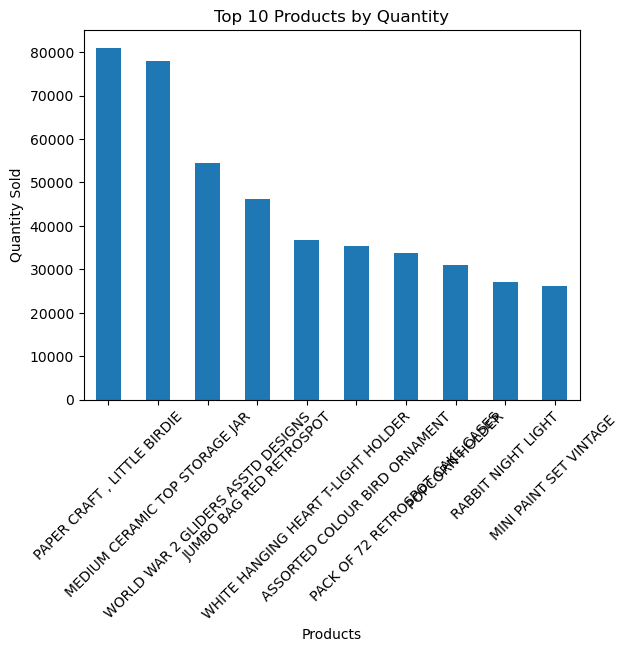

In [21]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar', title='Top 10 Products by Quantity')
plt.xlabel("Products")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()

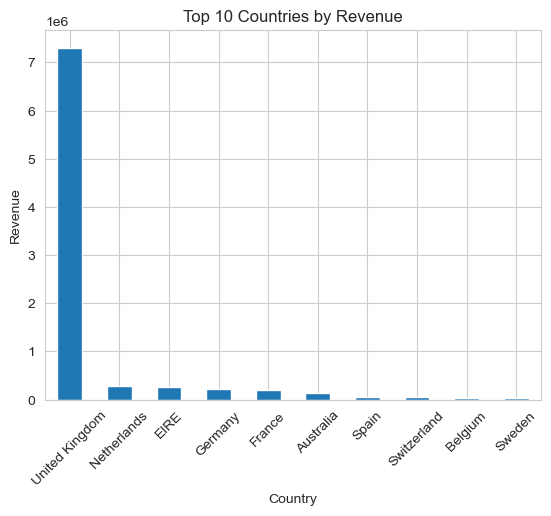

In [28]:
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

country_sales.plot(kind='bar', title='Top 10 Countries by Revenue')
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

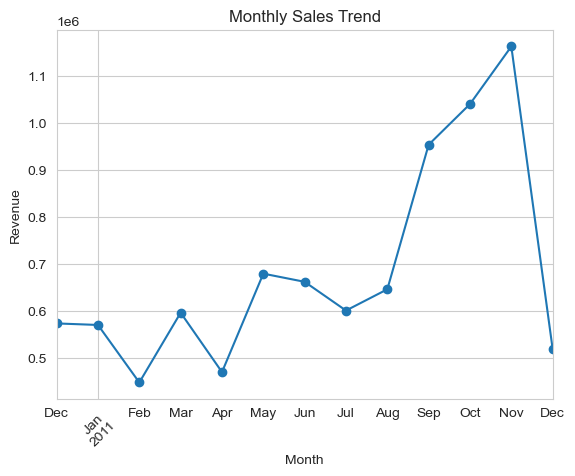

In [27]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = df.groupby('Month')['TotalPrice'].sum()

monthly_sales.plot(kind='line', marker='o', title='Monthly Sales Trend')
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

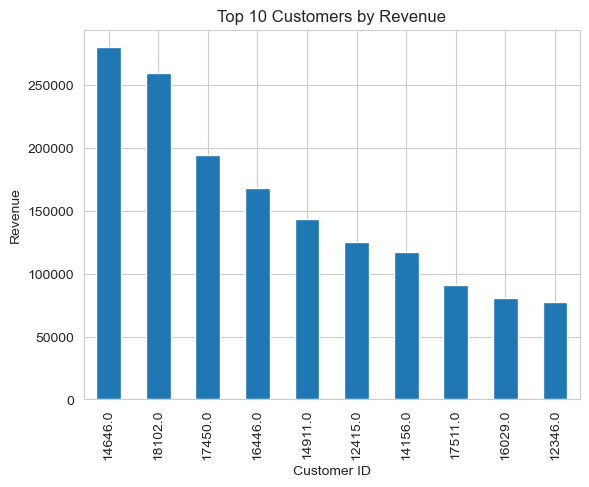

In [26]:
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)

top_customers.plot(kind='bar', title='Top 10 Customers by Revenue')
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.show()

In [25]:
import seaborn as sns
sns.set_style("whitegrid")